## Reviews

### Loading & Analysing data

In [1]:
import pandas as pd
reviews = pd.read_csv("Raw_Data/reviews.csv")

reviews.head()

,uid,profile,anime_uid,text,score,scores,link
0,255938,DesolatePsyche,34096,\n \n \n \n ...,8,"{'Overall': '8', 'Story': '8', 'Animation': '8...",https://myanimelist.net/reviews.php?id=255938
1,259117,baekbeans,34599,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",https://myanimelist.net/reviews.php?id=259117
2,253664,skrn,28891,\n \n \n \n ...,7,"{'Overall': '7', 'Story': '7', 'Animation': '9...",https://myanimelist.net/reviews.php?id=253664
3,8254,edgewalker00,2904,\n \n \n \n ...,9,"{'Overall': '9', 'Story': '9', 'Animation': '9...",https://myanimelist.net/reviews.php?id=8254
4,291149,aManOfCulture99,4181,\n \n \n \n ...,10,"{'Overall': '10', 'Story': '10', 'Animation': ...",https://myanimelist.net/reviews.php?id=291149


In [2]:
reviews.scores[0]
df = reviews.copy()

In [10]:
import pandas as pd
import ast

# Convert the string representation of dict to actual dict, then expand to columns
reviews['reviews.scores'] = reviews['scores'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

# Normalize the dicts into separate columns and join back
scores_df = pd.json_normalize(reviews['reviews.scores'])
scores_df.columns = [f'{col.lower()}' for col in scores_df.columns]  

reviews = pd.concat([reviews, scores_df], axis=1).drop(columns=['reviews.scores'])

# Convert the scores into numeric
cols = ['overall','story','animation','sound','character','enjoyment']
reviews[cols] = reviews[cols].apply(pd.to_numeric, errors='coerce') 

In [11]:
print(reviews['text'].iloc[0])


           
         
           
             
           
         
         
           more pics 
         
       
         
       
         
           Overall 
           8 
         
         
           Story 
           8 
         
                   
             Animation 
             8 
           
           
             Sound 
             10 
           
                 
           Character 
           9 
         
         
           Enjoyment 
           8 
         
       
     

                    
    First things first. My "reviews" system is explained on a blog entry. Which can be found through my profile. 
------ 
 
I'm going to keep this "review" more of a opinion of Gintama's overall and then this season specific. 
 
Anyhow. What I have always loved regarding Gintama, is its content of everything. I love the comedy, its absurd, random, can be vile, dirty, sweet, anyhow, everything. Have laughed countless times in this franchise. Also the humor they h

In [177]:
len(reviews)

192112

In [178]:
len(reviews[reviews.duplicated()])

61593

In [12]:
# No null data
reviews.isnull().sum()

uid          0
profile      0
anime_uid    0
text         0
score        0
scores       0
link         0
overall      0
story        0
animation    0
sound        0
character    0
enjoyment    0
dtype: int64

### Data Cleaning

- Max score is 11 - inconsistent
- Drop Scores, score, link
- cleaning text column to only keep the review
- Drop old text column
- Drop duplicates



In [13]:
reviews[cols] = reviews[cols].replace(11, 10)
reviews.drop(columns=['scores','score','link'], inplace=True)

In [14]:
import re

def clean_review(text):
    if pd.isna(text):
        return text
    
    # Remove everything before the actual review (scores section, "more pics", etc.)
    # The review starts after the dashes "------"
    if '------' in text:
        text = text.split('------', 1)[1]
    elif 'Enjoyment' in text:
        idx = text.find('Enjoyment') + len('Enjoyment') + 10
        text = text[idx:]
    
    # Remove "Helpful" and anything after it
    if 'Helpful' in text:
        text = text.split('Helpful')[0]
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove excessive whitespace and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

reviews['text_clean'] = reviews['text'].apply(clean_review)
reviews.drop(columns='text',inplace=True)


In [179]:
reviews.drop_duplicates(inplace=True)

### EDA

In [180]:
print(f'Number of unique users: {len(reviews.uid.unique())}')
print(f'Number of unique animes: {len(reviews.anime_uid.unique())}')
print(f'Total number of reviews: {len(reviews)}')

Number of unique users: 130519
Number of unique animes: 8113
Total number of reviews: 130519


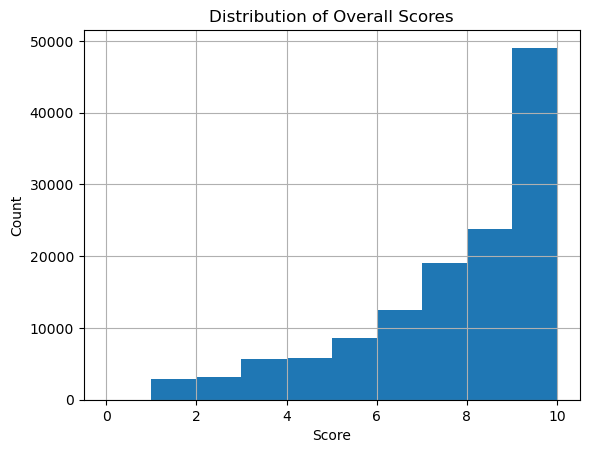

In [181]:
# Distribution of Scores
import matplotlib.pyplot as plt

reviews['overall'].hist(bins=10)
plt.title('Distribution of Overall Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

# a left skew as most scores are greater than 5
# most user are oportunistic raters

In [184]:
# Reviews per user
reviews_per_user = reviews['uid'].value_counts()
print(reviews_per_user.describe())

# Only one review per user


count    130519.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: count, dtype: float64


In [29]:
# Most reviewed animes ids
reviews_per_anime = reviews['anime_uid'].value_counts()
print(reviews_per_anime.head(10))

reviews[cols].corr()

anime_uid
1535     1708
9253     1558
32281    1436
11757    1292
5114     1274
4181     1194
4224     1140
9756     1130
10620    1082
2001      978
Name: count, dtype: int64


,overall,story,animation,sound,character,enjoyment
overall,1.000000,0.754433,0.526716,0.562030,0.752368,0.767562
story,0.754433,1.000000,0.703947,0.733753,0.859726,0.838138
animation,0.526716,0.703947,1.000000,0.811102,0.715981,0.721285
sound,0.562030,0.733753,0.811102,1.000000,0.750299,0.748149
character,0.752368,0.859726,0.715981,0.750299,1.000000,0.857180
enjoyment,0.767562,0.838138,0.721285,0.748149,0.857180,1.000000


In [185]:
for threshold in [10,20,30,50,75,100,200,300,400,500]:
    active = reviews_per_anime[reviews_per_anime >= threshold].index
    kept = reviews[reviews['anime_uid'].isin(active)]
    print(f'Min {threshold} reviews → {kept["anime_uid"].nunique()} animes, {len(kept)} reviews')

Min 10 reviews → 2549 animes, 115711 reviews
Min 20 reviews → 1673 animes, 105818 reviews
Min 30 reviews → 1192 animes, 95885 reviews
Min 50 reviews → 734 animes, 81750 reviews
Min 75 reviews → 518 animes, 71463 reviews
Min 100 reviews → 384 animes, 63294 reviews
Min 200 reviews → 191 animes, 44886 reviews
Min 300 reviews → 111 animes, 33955 reviews
Min 400 reviews → 74 animes, 27364 reviews
Min 500 reviews → 55 animes, 22720 reviews


In [186]:
for threshold in [2, 3, 5, 10]:
    active = reviews_per_user[reviews_per_user >= threshold].index
    kept = reviews[reviews['uid'].isin(active)]
    print(f'Min {threshold} reviews → {kept["uid"].nunique()} users, {len(kept)} reviews')

Min 2 reviews → 0 users, 0 reviews
Min 3 reviews → 0 users, 0 reviews
Min 5 reviews → 0 users, 0 reviews
Min 10 reviews → 0 users, 0 reviews


### EDA Summary
Review Scores are left skewed -> most scores are > 7 
Users are optimistic raters
users have only given one rating
Least correlation between overall score and sound score



### Conclusions
No Item or User based filter; as only 1 review per user.
Non Personalized Recommendations using Bayesian Score.
Content based recommendation for cold start.
Knowledge based using filters.
  
### We will also save the unfiltered data for non - personalized recommendations & content-based.

In [188]:
item_based = reviews[reviews['anime_uid'].isin(
    reviews_per_anime[reviews_per_anime >= 50].index
)]
item_based
print(f'Number of unique users: {len(item_based.uid.unique())}')
print(f'Number of unique animes: {len(item_based.anime_uid.unique())}')
print(f'Total number of reviews: {len(item_based)}')

Number of unique users: 81750
Number of unique animes: 734
Total number of reviews: 81750


### Save Data

In [287]:
# Only saving reviews since item based is not needed.
reviews.to_parquet('data/reviews.parquet', index=False)


## Animes

### Load Data

In [5]:
animes = pd.read_csv('Raw_Data/animes.csv')

In [6]:
animes.head()

,uid,title,synopsis,genre,aired,episodes,members,popularity,ranked,score,img_url,link
0,28891,Haikyuu!! Second Season,Following their participation at the Inter-Hig...,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82,https://cdn.myanimelist.net/images/anime/9/766...,https://myanimelist.net/anime/28891/Haikyuu_Se...
1,23273,Shigatsu wa Kimi no Uso,Music accompanies the path of the human metron...,"['Drama', 'Music', 'Romance', 'School', 'Shoun...","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83,https://cdn.myanimelist.net/images/anime/3/671...,https://myanimelist.net/anime/23273/Shigatsu_w...
2,34599,Made in Abyss,The Abyss—a gaping chasm stretching down into ...,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83,https://cdn.myanimelist.net/images/anime/6/867...,https://myanimelist.net/anime/34599/Made_in_Abyss
3,5114,Fullmetal Alchemist: Brotherhood,"""In order for something to be obtained, someth...","['Action', 'Military', 'Adventure', 'Comedy', ...","Apr 5, 2009 to Jul 4, 2010",64.0,1615084,4,1.0,9.23,https://cdn.myanimelist.net/images/anime/1223/...,https://myanimelist.net/anime/5114/Fullmetal_A...
4,31758,Kizumonogatari III: Reiketsu-hen,After helping revive the legendary vampire Kis...,"['Action', 'Mystery', 'Supernatural', 'Vampire']","Jan 6, 2017",1.0,214621,502,22.0,8.83,https://cdn.myanimelist.net/images/anime/3/815...,https://myanimelist.net/anime/31758/Kizumonoga...


In [14]:
print(f'Shape of anime df {animes.shape}')
print(f'Number of unique animes: {len(animes.uid.unique())}')


# 14920

Shape of anime df (14920, 13)
Number of unique animes: 14920


In [13]:
animes.isnull().sum()

uid             0
title           0
synopsis      637
genre           0
aired           0
episodes      442
members         0
popularity      0
ranked        369
score         336
img_url       152
link            0
base_title      0
dtype: int64

In [12]:
animes.ranked.describe()

count    14551.000000
mean      7332.135248
std       4235.512937
min          1.000000
25%       3659.500000
50%       7337.000000
75%      10992.500000
max      14675.000000
Name: ranked, dtype: float64

### Data Cleaning & Imputation
- Dropping Duplicates
- Dropping any anime that has a specific genre : |

In [11]:
import re
animes.drop_duplicates(subset=['title'], inplace=True)
animes = animes[~animes['genre'].str.contains('Hentai', na=False)]

animes['base_title'] = animes['title'].apply(lambda x: re.split(r'[°\'\u2019:!?().]', x)[0].strip())


### Save data

In [15]:
animes.to_parquet('data/animes.parquet')

## Profiles

In [241]:
profiles = pd.read_csv('Raw_Data/profiles.csv')

In [242]:
profiles

,profile,gender,birthday,favorites_anime,link
0,DesolatePsyche,Male,"Oct 2, 1994","['33352', '25013', '5530', '33674', '1482', '2...",https://myanimelist.net/profile/DesolatePsyche
1,baekbeans,Female,"Nov 10, 2000","['11061', '31964', '853', '20583', '918', '925...",https://myanimelist.net/profile/baekbeans
2,skrn,NaN,NaN,"['918', '2904', '11741', '17074', '23273', '32...",https://myanimelist.net/profile/skrn
3,edgewalker00,Male,Sep 5,"['5680', '849', '2904', '3588', '37349']",https://myanimelist.net/profile/edgewalker00
4,aManOfCulture99,Male,"Oct 30, 1999","['4181', '7791', '9617', '5680', '2167', '4382...",https://myanimelist.net/profile/aManOfCulture99
...,...,...,...,...,...
81722,lovelessxd,Female,"Aug 6, 1992","['853', '5114']",https://myanimelist.net/profile/lovelessxd
81723,Shattered_Angel,Female,"Sep 6, 1994","['150', '27', '1520', '121', '31452', '32995',...",https://myanimelist.net/profile/Shattered_Angel
81724,FluffyWalrus,Male,NaN,"['121', '43', '237', '202', '205']",https://myanimelist.net/profile/FluffyWalrus
81725,camco,Female,Sep 23,"['199', '4224', '7054', '13601', '14713']",https://myanimelist.net/profile/camco


### Data Cleaning
- only keeping profile and favorite anime
- drop duplicates
- if favorites is empty, remove row
- evaluate favorites to a list
- filtering users with atleast 3 favorite animes

In [277]:
profiles = profiles[['profile','favorites_anime']]
profiles.drop_duplicates(inplace=True)
profiles = profiles[~(profiles.favorites_anime == '[]')]

C:\Users\insiy\AppData\Local\Temp\ipykernel_8868\4101365555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profiles.drop_duplicates(inplace=True)


In [278]:
profiles['favorites_anime'] = profiles['favorites_anime'].apply(ast.literal_eval)

In [279]:
profiles.isna().sum()


profile            0
favorites_anime    0
dtype: int64

In [284]:
profiles['n_favorites'] = profiles['favorites_anime'].apply(len)
print(profiles['n_favorites'].describe())
print(f"\nUsers with less than 3 favorites: {(profiles['n_favorites'] < 3).sum()}")
print(f"Users with 5+ favorites: {(profiles['n_favorites'] >= 5).sum()}")
print(f"Users with 10+ favorites: {(profiles['n_favorites'] >= 10).sum()}")

count    37478.000000
mean         5.784887
std          2.967029
min          1.000000
25%          4.000000
50%          5.000000
75%          8.000000
max         20.000000
Name: n_favorites, dtype: float64

Users with less than 3 favorites: 5080
Users with 5+ favorites: 26308
Users with 10+ favorites: 7415


In [ ]:
# filter users with at least 3 favorites
profiles_filtered = profiles[profiles['n_favorites'] >= 3]
print(f"Users remaining: {len(profiles_filtered)}") 

Users remaining: 32398


### Save Data

In [286]:
profiles_filtered.to_parquet('data/profiles.parquet')

In [16]:
animes = pd.read_parquet('data/animes.parquet')

In [17]:
animes

,uid,title,synopsis,genre,aired,episodes,members,popularity,ranked,score,img_url,link,base_title,weighted_score
0,28891,Haikyuu!! Second Season,Following their participation at the Inter-Hig...,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...","Oct 4, 2015 to Mar 27, 2016",25.0,489888,141,25.0,8.82,https://cdn.myanimelist.net/images/anime/9/766...,https://myanimelist.net/anime/28891/Haikyuu_Se...,Haikyuu,8.752684
1,23273,Shigatsu wa Kimi no Uso,Music accompanies the path of the human metron...,"['Drama', 'Music', 'Romance', 'School', 'Shoun...","Oct 10, 2014 to Mar 20, 2015",22.0,995473,28,24.0,8.83,https://cdn.myanimelist.net/images/anime/3/671...,https://myanimelist.net/anime/23273/Shigatsu_w...,Shigatsu wa Kimi no Uso,8.796269
2,34599,Made in Abyss,The Abyss—a gaping chasm stretching down into ...,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...","Jul 7, 2017 to Sep 29, 2017",13.0,581663,98,23.0,8.83,https://cdn.myanimelist.net/images/anime/6/867...,https://myanimelist.net/anime/34599/Made_in_Abyss,Made in Abyss,8.772828
3,5114,Fullmetal Alchemist: Brotherhood,"""In order for something to be obtained, someth...","['Action', 'Military', 'Adventure', 'Comedy', ...","Apr 5, 2009 to Jul 4, 2010",64.0,1615084,4,1.0,9.23,https://cdn.myanimelist.net/images/anime/1223/...,https://myanimelist.net/anime/5114/Fullmetal_A...,Fullmetal Alchemist,9.205713
4,31758,Kizumonogatari III: Reiketsu-hen,After helping revive the legendary vampire Kis...,"['Action', 'Mystery', 'Supernatural', 'Vampire']","Jan 6, 2017",1.0,214621,502,22.0,8.83,https://cdn.myanimelist.net/images/anime/3/815...,https://myanimelist.net/anime/31758/Kizumonoga...,Kizumonogatari III,8.680956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19002,10075,Naruto x UT,All-new animation offered throughout UNIQLO cl...,"['Action', 'Comedy', 'Super Power', 'Martial A...","Jan 1, 2011",1.0,34155,2382,1728.0,7.50,https://cdn.myanimelist.net/images/anime/3/304...,https://myanimelist.net/anime/10075/Naruto_x_UT,Naruto x UT,7.172551
19003,35828,Miira no Kaikata,High school student Sora Kashiwagi is accustom...,"['Slice of Life', 'Comedy', 'Supernatural']","Jan 12, 2018 to Mar 30, 2018",12.0,61459,1648,1727.0,7.50,https://cdn.myanimelist.net/images/anime/1486/...,https://myanimelist.net/anime/35828/Miira_no_K...,Miira no Kaikata,7.291362
19004,10378,Shinryaku!? Ika Musume,"After regaining her squid-like abilities, Ika ...","['Slice of Life', 'Comedy', 'Shounen']","Sep 27, 2011 to Dec 25, 2011",12.0,67422,1547,1548.0,7.56,https://cdn.myanimelist.net/images/anime/6/301...,https://myanimelist.net/anime/10378/Shinryaku_...,Shinryaku,7.356492
19005,33082,Kingsglaive: Final Fantasy XV,"For years, the Niflheim Empire and the kingdom...",['Action'],"Jul 9, 2016",1.0,41077,2154,1544.0,7.56,https://cdn.myanimelist.net/images/anime/12/79...,https://myanimelist.net/anime/33082/Kingsglaiv...,Kingsglaive,7.258779


In [20]:
animes[animes.title == 'Kimi to Boku no Saigo no Senjou, Aruiwa Sekai ga Hajimaru Seisen']['img_url']

3043    https://cdn.myanimelist.net/images/anime/1635/...
Name: img_url, dtype: object

In [2]:
import pandas as pd

reviews = pd.read_parquet('data/reviews.parquet')